# Skin Cancer Detection Using Deep Learning
## Binary Classification (Benign vs. Malignant)
**Model**: ResNet‑18 pretrained on ImageNet  
**Baseline**: Random Forest on hand‑crafted features


### 1. Import Libraries


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
from scipy.special import softmax

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


### 2. Configuration


In [28]:
class Config:
    data_csv = "ISIC_2019_Training_Input/ISIC_2019_Training_GroundTruth.csv"
    image_dir = "ISIC_2019_Training_Input"
    batch_size = 128
    num_epochs = 15
    learning_rate = 1e-3
    num_workers = 0
    img_size = 224
    train_ratio = 0.7
    val_ratio = 0.15
    test_ratio = 0.15
    seed = 42
    model_save_path = "best_resnet18_binary.pth"
    results_dir = "results"
    benign_classes = ['NV', 'BKL']
    malignant_classes = ['MEL', 'BCC', 'AK', 'SCC', 'DF', 'VASC']
    target_classes = benign_classes + malignant_classes

config = Config()
os.makedirs(config.results_dir, exist_ok=True)
torch.manual_seed(config.seed)
np.random.seed(config.seed)


### 3. Build Image Index (Handles Subdirectories)


In [29]:
def build_image_index(image_dir):
    image_index = {}
    print(f"Scanning directory: {image_dir}")
    if not os.path.exists(image_dir):
        print(f"WARNING: Directory {image_dir} does not exist!")
        return image_index
    for root, dirs, files in os.walk(image_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                base_name = os.path.splitext(file)[0]
                full_path = os.path.join(root, file)
                image_index[base_name] = full_path
                image_index[file] = full_path
                if base_name.startswith('ISIC_'):
                    image_index[base_name] = full_path
    print(f"Found {len(image_index)} images in index")
    return image_index

image_index = build_image_index(config.image_dir)
print(f"Sample keys: {list(image_index.keys())[:5]}")


Scanning directory: ISIC_2019_Training_Input
Found 50662 images in index
Sample keys: ['ISIC_0024468', 'ISIC_0024468.jpg', 'ISIC_0024470', 'ISIC_0024470.jpg', 'ISIC_0024511']


### 4. Custom Dataset Class (Binary)


In [30]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, image_index, transform=None, binary=True):
        self.dataframe = dataframe
        self.image_index = image_index
        self.transform = transform
        self.binary = binary

    def __len__(self):
        return len(self.dataframe) if self.dataframe is not None else 0

    def _find_image_path(self, img_name):
        if img_name is None:
            return None
        if img_name in self.image_index:
            return self.image_index[img_name]
        base_name = os.path.splitext(img_name)[0]
        if base_name in self.image_index:
            return self.image_index[base_name]
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            if img_name + ext in self.image_index:
                return self.image_index[img_name + ext]
            if base_name + ext in self.image_index:
                return self.image_index[base_name + ext]
        return None

    def __getitem__(self, idx):
        if self.dataframe is None:
            raise ValueError("Dataframe is None")
        img_name = self.dataframe.iloc[idx]['image']
        img_path = self._find_image_path(img_name)
        if img_path is None:
            image = Image.new('RGB', (config.img_size, config.img_size), color='black')
        else:
            try:
                image = Image.open(img_path).convert('RGB')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                image = Image.new('RGB', (config.img_size, config.img_size), color='black')
        if self.binary:
            label = self.dataframe.iloc[idx]['binary_label']
        else:
            # fallback to multi-class
            for i, cls in enumerate(config.target_classes):
                if cls in self.dataframe.columns and self.dataframe.iloc[idx][cls] == 1:
                    label = i
                    break
        if self.transform:
            image = self.transform(image)
        return image, label, img_name

def find_image_path(img_name, image_index):
    if img_name in image_index:
        return image_index[img_name]
    base_name = os.path.splitext(img_name)[0]
    if base_name in image_index:
        return image_index[base_name]
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        if img_name + ext in image_index:
            return image_index[img_name + ext]
        if base_name + ext in image_index:
            return image_index[base_name + ext]
    return None


### 5. Load and Prepare Data (Binary Conversion)


Original dataset: 25331 rows
After removing UNK: 25331 rows
Available classes: ['NV', 'BKL', 'MEL', 'BCC', 'AK', 'SCC', 'DF', 'VASC']
After cleaning: 25331 rows

Binary class distribution:
Benign (0): 15499 samples
Malignant (1): 9832 samples

Checking image availability...
Images found: 25331 / 25331


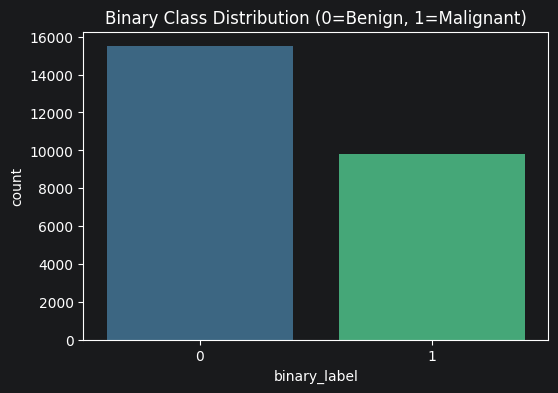

In [31]:
# Load CSV
df = pd.read_csv(config.data_csv)
print(f"Original dataset: {len(df)} rows")

# Remove UNK if present
if 'UNK' in df.columns:
    df = df[df['UNK'] != 1]
    print(f"After removing UNK: {len(df)} rows")

# Keep only target classes
available_classes = [c for c in config.target_classes if c in df.columns]
print(f"Available classes: {available_classes}")

# Keep only rows with exactly one class
df = df[df[available_classes].sum(axis=1) == 1]
print(f"After cleaning: {len(df)} rows")

# Add binary label: 1 = malignant, 0 = benign
def get_binary_label(row):
    for cls in config.malignant_classes:
        if row.get(cls, 0) == 1:
            return 1
    return 0

df['binary_label'] = df.apply(get_binary_label, axis=1)
print("\nBinary class distribution:")
print(f"Benign (0): {(df['binary_label']==0).sum()} samples")
print(f"Malignant (1): {(df['binary_label']==1).sum()} samples")

# Check image existence
print("\nChecking image availability...")
df['image_exists'] = df['image'].apply(lambda x: find_image_path(x, image_index) is not None)
print(f"Images found: {df['image_exists'].sum()} / {len(df)}")
missing_count = (~df['image_exists']).sum()
if missing_count > 0:
    print(f"Removing {missing_count} rows with missing images")
    df = df[df['image_exists']].drop(columns=['image_exists'])
    print(f"Remaining dataset size: {len(df)}")

# Create target column for easy viewing (original class)
def get_lesion_type(row):
    for cls in available_classes:
        if row[cls] == 1:
            return cls
    return None
df['target'] = df.apply(get_lesion_type, axis=1)

# Visualize binary distribution
plt.figure(figsize=(6,4))
sns.countplot(x='binary_label', data=df, palette='viridis')
plt.title("Binary Class Distribution (0=Benign, 1=Malignant)")
plt.savefig(os.path.join(config.results_dir, 'binary_distribution.png'))
plt.show()


### 6. Data Transforms


In [32]:
train_transform = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((config.img_size, config.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


### 7. Train/Val/Test Split (Stratified by binary label)


In [33]:
# First split: separate test set
train_val_df, test_df = train_test_split(
    df, test_size=config.test_ratio, random_state=config.seed,
    stratify=df['binary_label']
)

# Second split: separate train and validation
val_ratio_adjusted = config.val_ratio / (config.train_ratio + config.val_ratio)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_ratio_adjusted, random_state=config.seed,
    stratify=train_val_df['binary_label']
)

print(f"Train set: {len(train_df)} images")
print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")
print("\nBinary label distribution:")
print(f"Train: benign={sum(train_df['binary_label']==0)}, malignant={sum(train_df['binary_label']==1)}")
print(f"Val:   benign={sum(val_df['binary_label']==0)}, malignant={sum(val_df['binary_label']==1)}")
print(f"Test:  benign={sum(test_df['binary_label']==0)}, malignant={sum(test_df['binary_label']==1)}")


Train set: 17731 images
Validation set: 3800 images
Test set: 3800 images

Binary label distribution:
Train: benign=10849, malignant=6882
Val:   benign=2325, malignant=1475
Test:  benign=2325, malignant=1475


### 8. Create DataLoaders with Weighted Sampling


In [34]:
train_dataset = SkinLesionDataset(train_df, image_index, transform=train_transform, binary=True)
val_dataset = SkinLesionDataset(val_df, image_index, transform=val_transform, binary=True)
test_dataset = SkinLesionDataset(test_df, image_index, transform=val_transform, binary=True)

# Weighted sampler for training to handle imbalance
class_counts = [sum(train_df['binary_label']==0), sum(train_df['binary_label']==1)]
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
sample_weights = torch.zeros(len(train_dataset))
for idx in range(len(train_dataset)):
    _, label, _ = train_dataset[idx]
    sample_weights[idx] = class_weights[label]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, sampler=sampler,
                          num_workers=config.num_workers, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        num_workers=config.num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False,
                         num_workers=config.num_workers, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")


Train batches: 139, Val batches: 30, Test batches: 30


### 9. Random Forest Baseline (Hand‑crafted Features)


In [47]:
def extract_handcrafted_features(df, image_index, img_size=64):
    """Extract color statistics, histograms, and entropy for baseline."""
    features = []
    labels = []
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        img_name = row['image']
        img_path = find_image_path(img_name, image_index)
        if img_path is None:
            # fallback: black image
            img = Image.new('RGB', (img_size, img_size), color='black')
        else:
            img = Image.open(img_path).convert('RGB')
        img = img.resize((img_size, img_size))
        img_np = np.array(img) / 255.0  # float in [0,1]
        # Color statistics: mean and std per channel
        mean_rgb = img_np.mean(axis=(0,1))
        std_rgb = img_np.std(axis=(0,1))
        # Color histograms: 10 bins per channel
        hist_features = []
        for c in range(3):
            hist, _ = np.histogram(img_np[:,:,c], bins=10, range=(0,1))
            hist_features.extend(hist)
        # Entropy (grayscale approximation)
        gray = np.mean(img_np, axis=2)
        from skimage.measure import shannon_entropy
        entropy = shannon_entropy(gray)
        feat = np.concatenate([mean_rgb, std_rgb, hist_features, [entropy]])
        features.append(feat)
        labels.append(row['binary_label'])
    return np.array(features), np.array(labels)

print("Extracting hand-crafted features for baseline...")
X_train_base, y_train_base = extract_handcrafted_features(train_df, image_index, img_size=64)
X_test_base, y_test_base = extract_handcrafted_features(test_df, image_index, img_size=64)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=40, max_depth=15, random_state=config.seed, n_jobs=-1)
rf.fit(X_train_base, y_train_base)
y_pred_base = rf.predict(X_test_base)
y_proba_base = rf.predict_proba(X_test_base)[:, 1]

# Baseline metrics
base_roc_auc = roc_auc_score(y_test_base, y_proba_base)
base_acc = accuracy_score(y_test_base, y_pred_base)
base_bal_acc = balanced_accuracy_score(y_test_base, y_pred_base)
base_sensitivity = recall_score(y_test_base, y_pred_base, pos_label=1)
base_specificity = recall_score(y_test_base, y_pred_base, pos_label=0)
print("\n===== Random Forest Baseline =====")
print(f"ROC-AUC: {base_roc_auc:.4f}")
print(f"Accuracy: {base_acc:.4f}")
print(f"Balanced Accuracy: {base_bal_acc:.4f}")
print(f"Sensitivity (malignant recall): {base_sensitivity:.4f}")
print(f"Specificity (benign recall): {base_specificity:.4f}")


Extracting hand-crafted features for baseline...


100%|██████████| 3800/3800 [00:52<00:00, 72.58it/s]



===== Random Forest Baseline =====
ROC-AUC: 0.8537
Accuracy: 0.7805
Balanced Accuracy: 0.7584
Sensitivity (malignant recall): 0.6597
Specificity (benign recall): 0.8572


### 10. ResNet‑18 Model Definition (Binary)


In [48]:
class ResNet18Binary(nn.Module):
    def __init__(self, pretrained=True):
        super(ResNet18Binary, self).__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.model(x).squeeze(1)

model = ResNet18Binary(pretrained=True).to(device)

checkpoint_path = config.model_save_path
if os.path.exists(checkpoint_path):
    print(f"loading from {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))

    # Évaluer le modèle chargé sur l'ensemble de validation
    from sklearn.metrics import roc_auc_score
    model.eval()
    all_val_labels = []
    all_val_probs = []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_val_probs.extend(probs)
            all_val_labels.extend(labels.numpy())
    loaded_auc = roc_auc_score(all_val_labels, all_val_probs)
    print(f"ROC-AUC of loaded model on validation set: {loaded_auc:.4f}")
else:
    print("no checkpoint found")

# Loss, optimizer, scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_counts[0]/class_counts[1]]).to(device))
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print(f"Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters")

loading from best_resnet18_binary.pth
ROC-AUC of loaded model on validation set: 0.8832
Model loaded with 11,177,025 parameters


### 11. Training Loop with Early Stopping


In [ ]:
def compute_roc_auc(loader, model, device):
    model.eval()
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())
    return roc_auc_score(all_labels, all_probs)

# ------------------------------------------------------------
# Chargement du checkpoint s'il existe (AVANT la boucle)
# ------------------------------------------------------------
start_epoch = 0
best_val_auc = 0.0
patience_counter = 0
early_stop_patience = 2

if os.path.exists(config.model_save_path):
    print(f"Loading checkpoint from {config.model_save_path}")
    checkpoint = torch.load(config.model_save_path, map_location=device)

    # Check if it's a full checkpoint (dictionary with 'model_state_dict')
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_auc = checkpoint['best_val_auc']
        patience_counter = checkpoint['patience_counter']
        print(f"Resuming from epoch {start_epoch}, best AUC: {best_val_auc:.4f}, patience: {patience_counter}")
    else:
        # Old format: just the model's state_dict
        model.load_state_dict(checkpoint)
        print("Loaded old checkpoint (model only). Starting training from scratch (epoch 0).")
        start_epoch = 0
        best_val_auc = 0.0
        patience_counter = 0
else:
    print("No checkpoint found, starting from scratch.")

# ------------------------------------------------------------
# Boucle d'entraînement
# ------------------------------------------------------------
for epoch in range(start_epoch, config.num_epochs):
    model.train()
    train_loss = 0.0
    for images, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs}"):
        images, labels = images.to(device), labels.to(device).float()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    all_val_labels = []
    all_val_probs = []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_val_probs.extend(probs)
            all_val_labels.extend(labels.cpu().numpy())
    val_loss /= len(val_loader.dataset)
    val_auc = roc_auc_score(all_val_labels, all_val_probs)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

    # Sauvegarde du meilleur modèle (checkpoint complet)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_auc': best_val_auc,
            'patience_counter': patience_counter,
        }, config.model_save_path)
        print(f"  -> New best model saved (AUC={val_auc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping after {epoch+1} epochs")
            break

print(f"Training finished. Best validation AUC: {best_val_auc:.4f}")

Loading checkpoint from best_resnet18_binary.pth
Loaded old checkpoint (model only). Starting training from scratch (epoch 0).


Epoch 1/15:  58%|█████▊    | 81/139 [02:34<01:51,  1.93s/it]

### 12. Evaluation on Test Set



===== ResNet-18 Test Results =====
ROC-AUC: 0.8816
Accuracy: 0.7468
Balanced Accuracy: 0.7729
Sensitivity (malignant recall): 0.8895
Specificity (benign recall): 0.6563


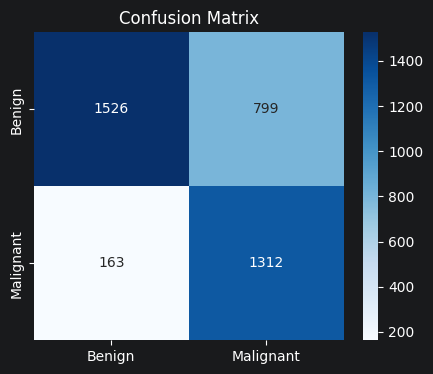

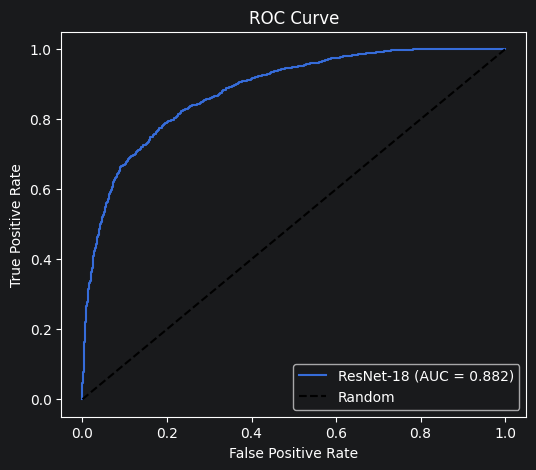


Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      0.66      0.76      2325
   Malignant       0.62      0.89      0.73      1475

    accuracy                           0.75      3800
   macro avg       0.76      0.77      0.75      3800
weighted avg       0.79      0.75      0.75      3800



In [38]:
# Load best model
model.load_state_dict(torch.load(config.model_save_path))
model.eval()

# Predictions
all_test_labels = []
all_test_probs = []
all_test_names = []
with torch.no_grad():
    for images, labels, names in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        all_test_probs.extend(probs)
        all_test_labels.extend(labels.numpy())
        all_test_names.extend(names)

y_true = np.array(all_test_labels)
y_pred = (np.array(all_test_probs) >= 0.5).astype(int)

# Primary metric: ROC-AUC
test_auc = roc_auc_score(y_true, all_test_probs)
print(f"\n===== ResNet-18 Test Results =====")
print(f"ROC-AUC: {test_auc:.4f}")

# Secondary metrics
test_acc = accuracy_score(y_true, y_pred)
test_bal_acc = balanced_accuracy_score(y_true, y_pred)
test_sensitivity = recall_score(y_true, y_pred, pos_label=1)
test_specificity = recall_score(y_true, y_pred, pos_label=0)
print(f"Accuracy: {test_acc:.4f}")
print(f"Balanced Accuracy: {test_bal_acc:.4f}")
print(f"Sensitivity (malignant recall): {test_sensitivity:.4f}")
print(f"Specificity (benign recall): {test_specificity:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.savefig(os.path.join(config.results_dir, 'confusion_matrix.png'))
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, all_test_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ResNet-18 (AUC = {test_auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(os.path.join(config.results_dir, 'roc_curve.png'))
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))


### 13. Calibration Error (ECE)


Expected Calibration Error (ECE): 0.1535


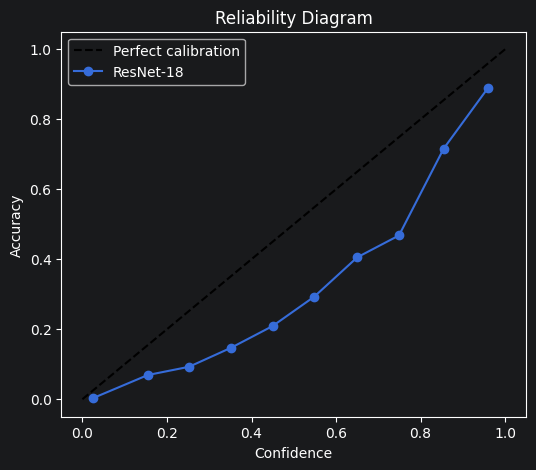

In [39]:
def compute_ece(probs, labels, n_bins=10):
    """Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        in_bin = (probs >= bin_boundaries[i]) & (probs < bin_boundaries[i+1])
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            avg_conf = np.mean(probs[in_bin])
            avg_acc = np.mean(labels[in_bin])
            ece += prop_in_bin * np.abs(avg_conf - avg_acc)
    return ece

all_test_probs = np.array(all_test_probs)
y_true = np.array(y_true)

# Puis calculez l'ECE
ece = compute_ece(all_test_probs, y_true)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

plt.figure(figsize=(6,5))
bins = np.linspace(0, 1, 11)
accuracies = []
confidences = []
for i in range(len(bins)-1):
    in_bin = (all_test_probs >= bins[i]) & (all_test_probs < bins[i+1])
    if np.sum(in_bin) > 0:
        accuracies.append(np.mean(y_true[in_bin]))
        confidences.append(np.mean(all_test_probs[in_bin]))
    else:
        accuracies.append(0)
        confidences.append(0)
plt.plot([0,1], [0,1], 'k--', label='Perfect calibration')
plt.plot(confidences, accuracies, marker='o', label='ResNet-18')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title('Reliability Diagram')
plt.legend()
plt.savefig(os.path.join(config.results_dir, 'reliability.png'))
plt.show()

### 14. CPU Inference Latency


In [40]:
# Switch to CPU and measure
cpu_model = ResNet18Binary(pretrained=False)
cpu_model.load_state_dict(torch.load(config.model_save_path, map_location='cpu'))
cpu_model.eval()
dummy_input = torch.randn(1, 3, config.img_size, config.img_size)

# Warm-up
for _ in range(10):
    _ = cpu_model(dummy_input)

# Measure
times = []
with torch.no_grad():
    for _ in range(50):
        start = time.perf_counter()
        _ = cpu_model(dummy_input)
        times.append(time.perf_counter() - start)
avg_latency = np.mean(times) * 1000  # ms
print(f"Average inference latency on CPU: {avg_latency:.2f} ms per image (batch_size=1)")


Average inference latency on CPU: 20.32 ms per image (batch_size=1)


### 15. Error Analysis (Highest‑Loss Misclassifications)


In [41]:
# Compute loss per sample
loss_fn = nn.BCEWithLogitsLoss(reduction='none')
model.eval()
losses = []
names = []
with torch.no_grad():
    for images, labels, img_names in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()
        outputs = model(images)
        sample_losses = loss_fn(outputs, labels).cpu().numpy()
        losses.extend(sample_losses)
        names.extend(img_names)

# Create dataframe of errors
error_df = pd.DataFrame({'image': names, 'true_label': y_true, 'pred_prob': all_test_probs, 'loss': losses})
error_df['pred_label'] = (error_df['pred_prob'] >= 0.5).astype(int)
error_df['correct'] = error_df['true_label'] == error_df['pred_label']
misclass_df = error_df[~error_df['correct']].copy()
misclass_df['loss_rank'] = misclass_df['loss'].rank(ascending=False)

# Top 10 highest-loss misclassifications per class
top_errors = []
for lbl in [0,1]:
    class_errors = misclass_df[misclass_df['true_label'] == lbl].nlargest(10, 'loss')
    top_errors.append(class_errors)
top_errors_df = pd.concat(top_errors)

print("\n===== Top 10 Highest-Loss Misclassifications =====")
print(top_errors_df[['image', 'true_label', 'pred_prob', 'loss']].to_string())

# Manual inspection placeholder
print("\nManual inspection required: examine the images listed above and tag causes:")
print("- Border ambiguity")
print("- Hair occlusion")
print("- Low contrast")
print("- Other")

# Save error analysis
top_errors_df.to_csv(os.path.join(config.results_dir, 'top_misclassifications.csv'), index=False)



===== Top 10 Highest-Loss Misclassifications =====
                         image  true_label  pred_prob      loss
1140              ISIC_0070619           0   0.994777  5.254640
2564              ISIC_0026569           0   0.992570  4.902289
2327              ISIC_0072098           0   0.991492  4.766793
2905              ISIC_0064942           0   0.991039  4.714867
184   ISIC_0012172_downsampled           0   0.989706  4.576179
2903              ISIC_0063728           0   0.989379  4.544877
2718              ISIC_0055795           0   0.988752  4.487605
121               ISIC_0065828           0   0.988004  4.423212
2462              ISIC_0069212           0   0.987984  4.421524
2232              ISIC_0027859           0   0.987632  4.392633
160               ISIC_0025316           1   0.040899  3.196656
1278              ISIC_0026989           1   0.073091  2.616043
2654  ISIC_0012434_downsampled           1   0.106112  2.243256
2089  ISIC_0012988_downsampled           1   0.11725

### 16. Comparison Table and Final Results


In [42]:
comparison = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Accuracy', 'Balanced Accuracy', 'Sensitivity', 'Specificity', 'ECE', 'Latency (ms)'],
    'Random Forest (Baseline)': [base_roc_auc, base_acc, base_bal_acc, base_sensitivity, base_specificity, np.nan, np.nan],
    'ResNet-18 (Ours)': [test_auc, test_acc, test_bal_acc, test_sensitivity, test_specificity, ece, avg_latency]
})
print("\n===== Final Comparison =====")
print(comparison.to_string(index=False))

# Save final results
comparison.to_csv(os.path.join(config.results_dir, 'final_results.csv'), index=False)

# Check if deep model outperforms baseline by ≥13% relative improvement in ROC-AUC
relative_improvement = (test_auc - base_roc_auc) / base_roc_auc
print(f"\nRelative improvement in ROC-AUC: {relative_improvement:.2%}")
if relative_improvement >= 0.13:
    print("SUCCESS: Deep model exceeds the 13% relative improvement target.")
else:
    print("WARNING: Relative improvement is below 13%. Consider further tuning or longer training.")


===== Final Comparison =====
           Metric  Random Forest (Baseline)  ResNet-18 (Ours)
          ROC-AUC                  0.853740          0.881573
         Accuracy                  0.780526          0.746842
Balanced Accuracy                  0.758433          0.772918
      Sensitivity                  0.659661          0.889492
      Specificity                  0.857204          0.656344
              ECE                       NaN          0.153511
     Latency (ms)                       NaN         20.321226

Relative improvement in ROC-AUC: 3.26%
